This notebook fits the deflector light profile of WGD 2038-4008 from a large cutout using isophote-based elliptical model.

### imports

In [1]:
import numpy as np
import os
import h5py
import joblib

import lenstronomy.Util.util as util
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Plots import chain_plot
from lenstronomy.Sampling.parameters import Param
#from lenstronomy.Analysis.lens_analysis import LensAnalysis
from lenstronomy.Util import mask_util
from lenstronomy.Data.coord_transforms import Coordinates
from lenstronomy.Util.util import array2image


from lenstronomy.Util import param_util

cwd = os.getcwd()
base_path, _ = os.path.split(cwd)
print('Base directory path:', base_path)

Base directory path: /Users/ajshajib/Research/time_delay_cosmography/J2038


### plot settings

In [2]:
import matplotlib as mpl
import paperfig as pf

msh_cmap = pf.msh_cmap
msh_cmap2 = pf.msh_cmap2

pf.set_fontscale(2.)

### functions

In [4]:
from photutils import detect_threshold
from astropy.convolution import Gaussian2DKernel
from astropy.stats import gaussian_fwhm_to_sigma
from photutils import detect_sources
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils import deblend_sources
import numpy as np
import astropy.units as u
from photutils import source_properties, EllipticalAperture
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize


def get_mask(large_image, bkg_rms):
    """
    Create a mask covering the nearby stars/galaxies.
    """
    #threshold = detect_threshold(data, nsigma=2.)

    threshold = (3.0 * bkg_rms)  

    sigma = 6.0 * gaussian_fwhm_to_sigma  # FWHM = 3.
    kernel = Gaussian2DKernel(sigma, x_size=3, y_size=3)
    kernel.normalize()
    segm = detect_sources(large_image, threshold, npixels=5, filter_kernel=kernel)


    norm = ImageNormalize(stretch=SqrtStretch())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
    ax1.imshow(large_image, origin='lower', cmap='Greys_r', norm=norm)
    ax1.set_title('Data')
    cmap = segm.make_cmap(random_state=12345)
    ax2.imshow(segm, origin='lower', cmap=cmap)
    ax2.set_title('Segmentation Image')


    segm_deblend = deblend_sources(large_image, segm, npixels=9,
                                   filter_kernel=kernel, nlevels=32,
                                   contrast=0.01)


    cat = source_properties(large_image, segm_deblend)
    r = 3.  # approximate isophotal extent
    apertures = []
    for obj in cat:
        position = np.transpose((obj.xcentroid.value, obj.ycentroid.value))
        a = obj.semimajor_axis_sigma.value * r
        b = obj.semiminor_axis_sigma.value * r
        theta = obj.orientation.to(u.rad).value
        apertures.append(EllipticalAperture(position, a, b, theta=theta))


    norm = ImageNormalize(stretch=SqrtStretch())
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12.5))
    ax1.imshow(large_image, origin='lower', cmap='Greys_r', norm=norm)
    ax1.set_title('Data')
    cmap = segm_deblend.make_cmap(random_state=12345)
    ax2.imshow(segm_deblend, origin='lower', cmap=cmap)
    ax2.set_title('Segmentation Image')
    for aperture in apertures:
        aperture.plot(axes=ax1, color='white', lw=1.5)
        aperture.plot(axes=ax2, color='white', lw=1.5)

    a = np.array(segm_deblend)

    s = set(a.flatten())
    area = []

    for num in s:
        if num == 0:
            continue
        counter = np.zeros_like(a)
        counter[a == num] = 1
        area.append(np.sum(counter))

    central_id = list(s)[np.argmax(area)]+1

    a[a == central_id] = 0

    plt.matshow(a, origin='lower')
    plt.title('initial segmented mask')
    plt.show()

    kernel = np.ones((11, 11),np.uint8)

    dilation = cv2.dilate(a.astype(np.uint8), kernel, iterations=1)

    plt.matshow(dilation, origin='lower')
    plt.title('dilated mask')
    plt.show()
    
    large_mask = np.zeros_like(dilation)
    large_mask[dilation == 0] = 1

    plt.matshow(np.log10(large_image*large_mask), origin='lower')
    plt.show()
    
    return large_mask

# Fit profiles

In [5]:
import warnings
warnings.filterwarnings('ignore')
import cv2
import copy
import h5py

import paperfig as pf
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import coloripy as cp

import lenstronomy.Util.class_creator as class_creator
from lenstronomy.ImSim.MultiBand.single_band_multi_model import SingleBandMultiModel

### load a model run to subtract the lensed arcs and QSO images from the deflector 

In [ ]:
job_name_out = '2038_run139_0_1_2_0_0'

input_temp = os.path.join(base_path, 'temp', job_name_out +'.txt')
output_temp = os.path.join(base_path, 'temp', job_name_out +'_out.txt')

f = open(output_temp, 'rb')
[input_, output_] = joblib.load(f)
f.close()

fitting_kwargs_list, kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params, init_samples = input_

kwargs_result, multi_band_list_out, fit_output, _ = output_

band_index = 2

kwargs_data, kwargs_psf, _ = multi_band_list_out[band_index]

walker_ratio = 8

mcmc_repeat = 2

samples_mcmc = np.array(fit_output[-1][1])

print('Shape of MCMC chain:', samples_mcmc.shape)

n_params = samples_mcmc.shape[1]

n_walkers = 8 * n_params
n_step = int(samples_mcmc.shape[0] / n_walkers)

print('n_step: {}, n_walkers: {}, n_params: {}'.format(n_step, n_walkers, n_params))

chain = np.empty((n_walkers, n_step, n_params))


for i in np.arange(n_params):
    samples = samples_mcmc[:, i].T
    chain[:,:,i] = samples.reshape((n_step, n_walkers)).T


mean_pos = np.zeros((n_params, n_step))
median_pos = np.zeros((n_params, n_step))
std_pos = np.zeros((n_params, n_step))
q16_pos = np.zeros((n_params, n_step))
q84_pos = np.zeros((n_params, n_step))

for i in np.arange(n_params):
    for j in np.arange(n_step):
        mean_pos[i][j] = np.mean(chain[:, j, i])
        median_pos[i][j] = np.median(chain[:, j, i])
        std_pos[i][j] = np.std(chain[:, j, i])
        q16_pos[i][j] = np.percentile(chain[:, j, i], 16.)
        q84_pos[i][j] = np.percentile(chain[:, j, i], 84.)
        
burnin = -1
last = n_step

medians = []

for i in range(n_params):
    medians.append(np.median(median_pos[i][burnin:last]))

param_class = Param(kwargs_model,
                kwargs_params['lens_model'][2], 
                kwargs_params['source_model'][2],
                kwargs_params['lens_light_model'][2],
                kwargs_params['point_source_model'][2],
                kwargs_lens_init=kwargs_params['lens_model'][0], 
                **kwargs_constraints
               )

kwargs_median = param_class.args2kwargs(medians)

**Here, we subtract the lensed arcs and the quasar images from the large cutout image.**

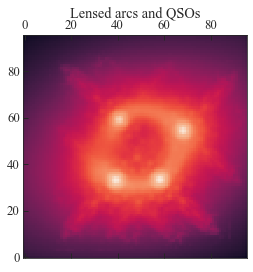

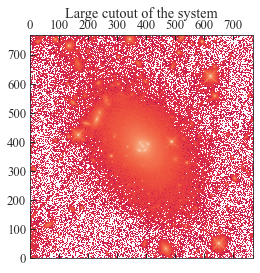

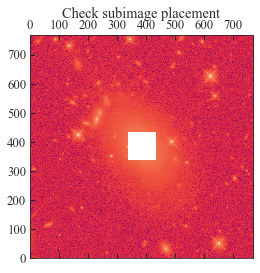

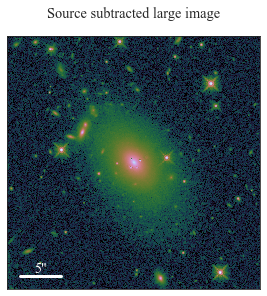

In [7]:
from rgb_functions import *

mask_list = kwargs_likelihood['image_likelihood_mask_list']
band_bool = [True] * 3
band_bool[band_index] = True

pf.set_fontscale(1.6)
fontsize = pf.mnras_figcaption_fontsize*1.6



image_model = class_creator.create_im_sim(multi_band_list_out, kwargs_data_joint['multi_band_type'], 
                                          kwargs_model,
                                          bands_compute=band_bool,
                                          likelihood_mask_list=mask_list)

model, error_map, cov_param, param = image_model.image_linear_solve(inv_bool=True, **kwargs_median)
    

band_model = SingleBandMultiModel(multi_band_list_out, kwargs_model, likelihood_mask_list=mask_list,
                                  band_index=band_index)

kwargs_lens_partial, kwargs_source_partial, kwargs_lens_light_partial, kwargs_ps_partial, _kwargs_extinction_partial = band_model.select_kwargs(**kwargs_median)
_kwargs_lens_partial, _kwargs_source_partial, _kwargs_lens_light_partial, _kwargs_ps_partial = band_model.update_linear_kwargs(param[band_index], kwargs_lens_partial, kwargs_source_partial, kwargs_lens_light_partial, kwargs_ps_partial)


data = kwargs_data['image_data']

lensed_arcs = band_model.image(_kwargs_lens_partial, _kwargs_source_partial, _kwargs_lens_light_partial,
                                          _kwargs_ps_partial, unconvolved=False, source_add=True,
                                          lens_light_add=False, point_source_add=True)

lensed_source = lensed_arcs #data - lensed_arcs

plt.matshow(np.log10(lensed_arcs), origin='lower')
plt.title('Lensed arcs and QSOs')
plt.show()

filt = 'F160W'
data_filename = '../data/data_f160w_large_cutout.hdf5'
local_data_filename = data_filename #os.path.join(base_path, 'data', data_filename)
f = h5py.File(local_data_filename, "r")

dset = f['image_data'][()]
bkg_rms = f['background_rms'][()]
wht_map = f['exposure_map'][()]
ra_at_xy_0 = f['ra_at_xy_0'][()]
dec_at_xy_0 = f['dec_at_xy_0'][()]
Matrix_inv = f['transform_pix2angle'][()]
f.close()

kwargs_data_large = {'image_data': dset, 
               'background_rms': bkg_rms,
               'noise_map': None,
               'exposure_time': wht_map,
               'ra_at_xy_0': ra_at_xy_0,
               'dec_at_xy_0': dec_at_xy_0, 
               'transform_pix2angle': Matrix_inv
               }

plt.matshow(np.log10(dset), origin='lower')
plt.title('Large cutout of the system')
plt.show()

result = cv2.matchTemplate(data.astype(np.float32), dset.astype(np.float32), cv2.TM_CCOEFF_NORMED)
match = np.unravel_index(result.argmax(),result.shape)

large_image = copy.deepcopy(dset)
large_image[match[0]:match[0]+len(lensed_source), match[1]:match[1]+len(lensed_source)] -= data

plt.matshow(np.log10(np.abs(large_image)), origin='lower')
plt.title('Check subimage placement')
plt.show()

large_image = copy.deepcopy(dset)
large_image[match[0]:match[0]+len(lensed_source), match[1]:match[1]+len(lensed_source)] -= lensed_source*mask_list[band_index]

fig = plt.figure(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))
ax = fig.add_subplot(111)
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title('Source subtracted large image')

add_scale_bar(ax, length=5, fontsize=14, scale_text=None);
    
ax.set_xticks([])
ax.set_yticks([])
plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/source_subtracted_large_coutout.pdf', 
            bbox_inches='tight')
plt.show()

#large_mask = get_mask(large_image, bkg_rms)

#import numpy.ma as ma

#masked_data = ma.masked_array(large_image, 1-large_mas#

## Fit isophotes using `photutils`

In [8]:
from photutils.isophote import Ellipse, EllipseGeometry
from photutils.isophote import build_ellipse_model

**First fit the isophotes in the inner region.**

In [9]:
g = EllipseGeometry(242.+96*1.5, 240+96*1.5, 60., 0.3, 120./180.*np.pi)
g.find_center(large_image)

ellipse = Ellipse(large_image, geometry=g)
isolist = ellipse.fit_image(integrmode='median', sclip=3.0, nclip=3, fflag=0.7, maxsma=90.)

INFO: Found center at x0 = 386.0, y0 = 384.0 [photutils.isophote.geometry]


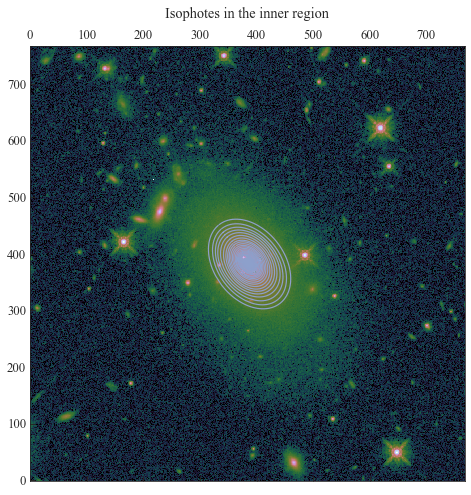

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title("Isophotes in the inner region")
#ax.set_xlim([300, 900])
#ax.set_ylim([700, 1200])

# go to the outermost successfully fitted ellipse at sma=235
isos = []
for sma in isolist.to_table()['sma']:
    iso = isolist.get_closest(sma)
    isos.append(iso)
    x, y, = iso.sampled_coordinates()
    plt.plot(x, y, color=pf.cb2_blue)



In [11]:
isolist.to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_err,grad_rerr,x0,x0_err,y0,y0_err,ndata,flag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,float64,float64,float64,int64,int64,int64,int64
0.0,28.0619827161827,0.0,0.0,0.0,0.0,0.0,0.0,None,None,385.60531717460145,0.0,383.98486373160745,0.0,1,0,0,0
0.5111130767700377,27.885099020518705,0.012606525410016826,0.8327345020516936,0.023657999332470706,178.43681680772332,1.4891487057530277,-0.18366179416864492,0.2951416878360741,1.6069846707751547,385.60531717460145,0.03619638725741079,383.98486373160745,0.006514280706248421,13,0,50,2
0.5622243844470415,27.80850384452227,0.015144420965528742,0.7949390992646758,0.01012388732096452,178.43681680772332,0.646589318153128,-0.5842396943022062,0.34526091886312904,0.590957653562885,385.55168608477055,0.013898313219953079,383.9863272953446,0.0030546028572869966,13,0,11,0
0.6184468228917457,27.577173215775947,0.03147876667890665,0.6556711148779377,0.012235083281624757,175.92809913145027,0.8492650847919286,-1.5344941485890269,0.9848552475740322,0.6418110153626916,385.52761021421463,0.010982931151196985,383.97537587977877,0.004095845546223427,13,0,10,0
0.6802915051809203,27.21909741557384,0.04185475001767043,0.4521405558201779,0.014856532640244021,171.777643291603,1.2988098316624659,-2.438698817950629,1.0950090640583767,0.44901365268982757,385.52470375275414,0.009177763381927523,383.95296713126083,0.005490072015250596,13,0,11,0
0.7483206556990124,26.815284210389258,0.054949626987314475,0.26769163079013814,0.01834255639470035,163.2894564221081,2.4200154433478374,-3.1596847520850813,1.2144797861769288,0.3843673915176163,385.53610068410063,0.009234750511229456,383.93741774302526,0.007505630645966563,13,0,10,0
0.8231527212689137,26.449979287690876,0.0489910740366386,0.17593001001998818,0.015414246831104591,149.12221296487974,2.9416654086634924,-3.4289121160386653,1.0235382122344994,0.2985023172355222,385.51395203992865,0.007475267981594819,383.9316842393311,0.007024389732200826,13,0,10,0
0.9054679933958051,26.209976843270834,0.05140993510465374,0.17520042214909126,0.013693292367270047,136.63110172697037,2.6203681821409157,-3.686581778467822,0.8793054837362801,0.23851511686843083,385.51117178947885,0.007107918533579725,383.9247030013527,0.007055401062864525,13,0,10,0


Check the intensity along the isophotes. For a good fit the same colored dots should follow horizontal lines.

Text(0, 0.5, 'Intensity')

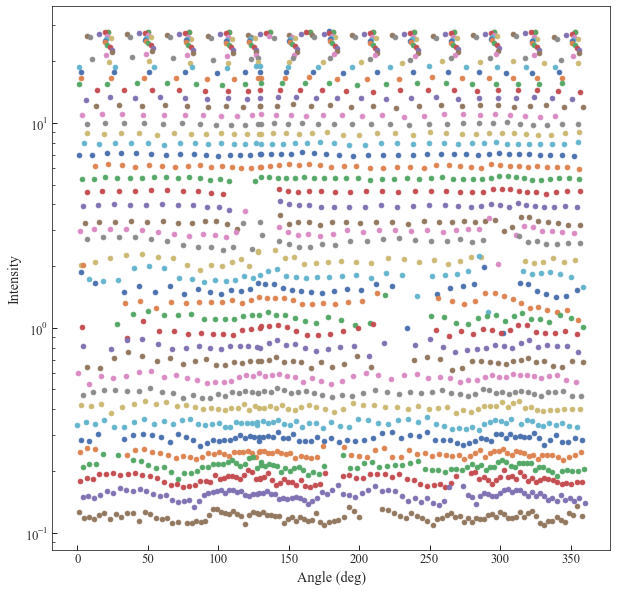

In [12]:
plt.figure(figsize=(10, 10))

for iso in isos:
    angles = ((iso.sample.values[0] + iso.sample.geometry.pa) / np.pi*180.) % 360.
    plt.scatter(angles, iso.sample.values[2])
    
plt.yscale('log')
plt.xlabel("Angle (deg)")
plt.ylabel("Intensity")

Plot the isophote-based model for the inner region.

Text(0.5, 1.05, 'Inner region model')

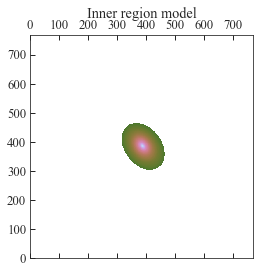

In [13]:
model_image = build_ellipse_model(large_image.shape, isolist)
#residual = data - model_image

plt.matshow(np.log10(model_image), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
plt.title('Inner region model')

In [14]:
#plt.matshow(np.log10(model_image), origin='lower')

**Fit the outer region. The step sizes between subsequent isophotes are different in the outer region.**

In [15]:
g = EllipseGeometry(242.+96*1.5, 240+96*1.5, 60., 0.3, 120./180.*np.pi)
g.find_center(large_image)

ellipse = Ellipse(large_image, geometry=g)
isolist_outer = ellipse.fit_image(integrmode='median', step=0.1, minsma=90.,
                                       maxsma=450., fflag=0.3, sclip=3.0, nclip=3)

INFO: Found center at x0 = 386.0, y0 = 384.0 [photutils.isophote.geometry]


In [16]:
isolist_outer.to_table()

sma,intens,intens_err,ellipticity,ellipticity_err,pa,pa_err,grad,grad_err,grad_rerr,x0,x0_err,y0,y0_err,ndata,flag,niter,stop_code
,,,,,deg,deg,,,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64
54.54545454545455,0.28965524270419357,0.0012114046074441715,0.2898848550746113,0.0008357897806399888,127.72279858580947,0.09319537243938399,-0.008623166158046392,0.0002790281892384501,0.03235797433615322,386.1111620836201,0.026317142774510645,383.2332867181292,0.02577870905845444,76,2,2,5
60.0,0.24261979093303143,0.000921356319330075,0.2898848550746113,0.0009298262775113573,127.72279858580947,0.10544028756545298,-0.005574723214014088,0.0002484942913401336,0.044575180112162896,386.1111620836201,0.032450804627966255,383.2332867181292,0.03138639165596333,81,5,20,0
66.0,0.21074805838587618,0.0011686744711854383,0.2950337416911899,0.001148758389848073,128.82108164836677,0.1294571057792706,-0.004848248933766603,0.00023504667261644243,0.04848073517418065,386.4346654523647,0.044283864784363094,382.88440787226835,0.043534317288752906,89,4,10,0
72.60000000000001,0.18292079593592084,0.0009007443767332728,0.3094258116635197,0.0008148243648839845,128.02299002637935,0.09408802876515218,-0.00436443779097808,0.00016872955407435118,0.03866008914667988,386.9118377370527,0.03591091749022127,381.9620829686291,0.03607305286553354,94,4,10,0
79.86000000000001,0.15258991039625489,0.0007684873529664628,0.31307132011879407,0.0007304917438575446,127.61727076730675,0.07894545966485259,-0.003684057687830993,0.0001229400002665724,0.033370813023005055,387.4593321351917,0.03445862040861207,381.46412295693193,0.03527522880529727,101,2,10,0
87.84600000000002,0.11973394913094065,0.0005367885090008216,0.2961485414903627,0.0006599303181486015,127.66151919923432,0.06747078954050643,-0.0027135521699122086,9.419340531118739e-05,0.03471221462244259,387.5802158392015,0.03219069330041896,381.99511347668897,0.0328261386789466,107,4,10,0
96.63060000000003,0.09695723977955904,0.0005281147050912082,0.3001107530895015,0.0007473962941537718,127.66151919923432,0.07486005404062036,-0.002099036184921639,7.683305143717501e-05,0.03660396709170754,386.6457930437448,0.03999092124165701,383.4191565710117,0.04107899942228893,110,6,10,0
106.29366000000005,0.07862380639366481,0.00047318062089365135,0.3118685895415754,0.0008923849495132847,129.41222575027314,0.09786524454476342,-0.0012802063079377602,6.591498490565618e-05,0.05148778325568192,385.91907408279644,0.05683230114740198,384.7627090580654,0.059667379527411406,115,4,10,0


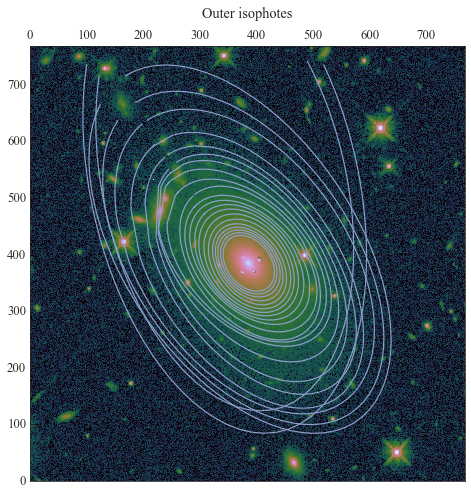

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(np.log10(np.abs(large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title("Outer isophotes")

#ax.set_xlim(limits)
#ax.set_ylim(limits)

isos = []
for sma in isolist_outer.to_table()['sma']:
    iso = isolist_outer.get_closest(sma)
    isos.append(iso)
    x, y, = iso.sampled_coordinates()
    plt.plot(x, y, color=pf.cb2_blue)

Text(0, 0.5, 'Intensity')

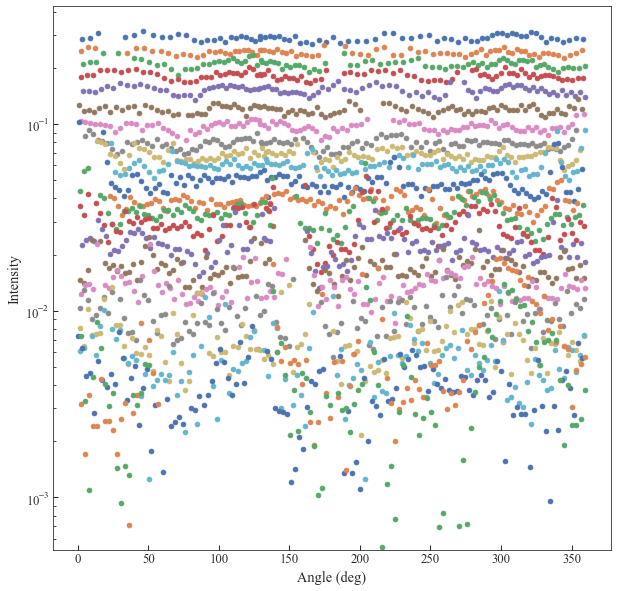

In [18]:
plt.figure(figsize=(10, 10))

for iso in isos:
    angles = ((iso.sample.values[0] + iso.sample.geometry.pa) / np.pi*180.) % 360.
    plt.scatter(angles, iso.sample.values[2])
    

plt.yscale('log')
plt.xlabel("Angle (deg)")
plt.ylabel("Intensity")



Combine the isophotes from inner region and outer region. Drop the last few isophotes in the outer region that are improperly fit.

In [19]:
isolist_full = isolist + isolist_outer[6:-2]

In [20]:
model_image = build_ellipse_model(large_image.shape, isolist_full)
#residual = data - model_image

#plt.matshow(np.log10(model_image), origin='lower')

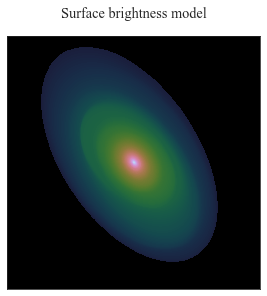

In [21]:
fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

ax.matshow(np.log10(model_image+1e-3), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)

ax.set_title('Surface brightness model')

ax.set_xticks([])
ax.set_yticks([])

plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/large_coutout_model.pdf', 
            bbox_inches='tight')
plt.show()


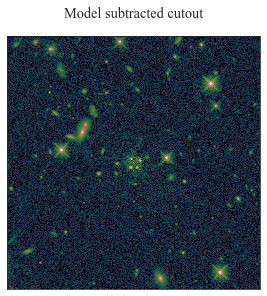

In [22]:
fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

ax.matshow(np.log10(np.abs(-model_image + large_image)), origin='lower', cmap=pf.cmap, 
           vmax=np.log10(np.abs(large_image)).max(), vmin=-3.)
ax.set_title('Model subtracted cutout')

ax.set_xticks([])
ax.set_yticks([]);


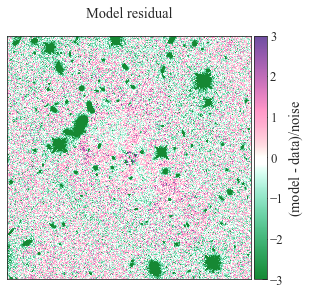

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


fig, ax = plt.subplots(figsize=pf.get_fig_size(width=2*pf.mnras_textwidth/3., height_ratio=1.))

noise = np.sqrt(np.abs(kwargs_data_large['image_data'] / kwargs_data_large['exposure_time']) + kwargs_data_large['background_rms']**2)

cbar = ax.matshow((model_image - large_image)/noise, origin='lower', cmap=msh_cmap2, vmax=3, vmin=-3)

ax.set_title('Model residual')

ax.set_xticks([])
ax.set_yticks([])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

plt.colorbar(cbar, cax=cax, label=r'(model - data)$/$noise')

plt.savefig('/Users/ajshajib/Dropbox/Papers_Proposals/2038_model/figures/large_coutout_model_residual.pdf', 
            bbox_inches='tight')
plt.show()


### Find half-light radius

In [24]:
from photutils import CircularAperture
from photutils import aperture_photometry

positions = [(242+96*1.5, 240+96*1.5)]


total_flux = np.sum(model_image)

for r in range(1, 200):
    aperture = CircularAperture(positions, r=r)

    phot_table = aperture_photometry(model_image, aperture)
    if phot_table[0]['aperture_sum'] >= total_flux/2.:
        break
print("Pixels:", r, ", Radius: ", r * 0.08, "arcsecond")

Pixels: 40 , Radius:  3.2 arcsecond


## Fit MGE

Here we fit a MGE to the light model to use the MGE light profiles in the kinematic computation.

In [25]:
import mgefit
from mgefit.find_galaxy import find_galaxy
from mgefit.mge_fit_1d import mge_fit_1d
from mgefit.sectors_photometry import sectors_photometry
from mgefit.mge_fit_sectors import mge_fit_sectors
from mgefit.mge_print_contours import mge_print_contours
from mgefit.mge_fit_sectors_twist import mge_fit_sectors_twist
from mgefit.sectors_photometry_twist import sectors_photometry_twist
from mgefit.mge_print_contours_twist import mge_print_contours_twist


### fit Gaussians to the PSF 

In [26]:
mean_psf_profile = (np.sum(kwargs_psf['kernel_point_source'], axis=0) + np.sum(kwargs_psf['kernel_point_source'], axis=1))/2.

psf_size = len(mean_psf_profile)

one_sided_psf_profile = mean_psf_profile[:int((psf_size-1)/2)+1][::-1] + mean_psf_profile[-int((psf_size-1)/2)-1:]

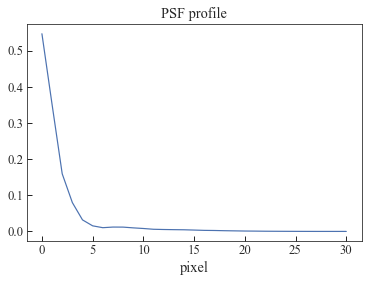

In [27]:
from scipy.interpolate import interp1d

n = 100  # number of sampled points
x = np.geomspace(0.01, 30, n)  # logarithmically spaced radii
y = interp1d(np.arange(len(one_sided_psf_profile)), one_sided_psf_profile)(x)  # The profile must be logarithmically sampled!
    
plt.plot(one_sided_psf_profile)
plt.title('PSF profile')
plt.xlabel('pixel')
plt.show()



Iteration: 1  chi2: 10.09 Nonzero: 7/9
Residuals > 10%: Change `inner_slope` or `outer_slope` or increase `ngauss`
Iteration: 5  chi2: 2.136 Nonzero: 8/8
############################################
 Computation time: 0.04 seconds
 Total Iterations:  5
Nonzero Gaussians:  8
 Unused Gaussians:  1
 Chi2: 2.136 
 STDEV: 0.1446
 MEANABSDEV: 0.06214
############################################
 Total_Counts      Sigma
############################################
  2.68403e-05   0.00732627
  0.000845859    0.0356764
   0.00518134     0.147048
   0.00841796     0.179126
    0.0180115     0.349905
     0.296639      0.80452
      1.30275      1.64478
     0.361306      7.71367
############################################


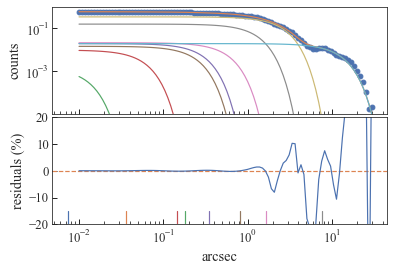

In [28]:
p = mge_fit_1d(x, y, plot=True, ngauss=9)

In [29]:
p.sol

array([[2.68402841e-05, 8.45858927e-04, 5.18133732e-03, 8.41796269e-03,
        1.80114870e-02, 2.96638553e-01, 1.30274812e+00, 3.61305893e-01],
       [7.32627143e-03, 3.56763809e-02, 1.47047910e-01, 1.79125851e-01,
        3.49904638e-01, 8.04519840e-01, 1.64478218e+00, 7.71367478e+00]])

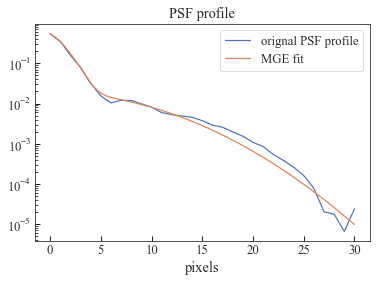

In [30]:
plt.plot(one_sided_psf_profile, label='orignal PSF profile')
plt.plot(p.x, np.sum(p.gauss*p.sol[0, :], axis=1), label='MGE fit')
plt.yscale('log')
plt.title('PSF profile')
plt.xlabel('pixels')
plt.legend()
plt.show()


### fit MGE to the galaxy model

 Pixels used: 176947
 Peak Img[j, k]: 384 385
 Mean (j, k): 383.32 385.28
 Theta (deg): 53.3
 Astro PA (deg): 36.7
 Eps: 0.395
 Major axis (pix): 314.5


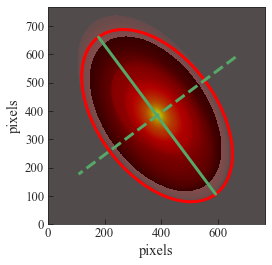

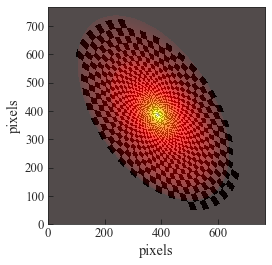

Iteration: 1  chi2: 6.662  Nonzero: 16/20
Iteration: 11  chi2: 6.081  Nonzero: 11/20
Iteration: 21  chi2: 1.175  Nonzero: 14/20
Nonzero Gaussians: 14/20
Eliminating not useful Gaussians...
ngauss: 13           chi2: 1.18
ngauss: 12           chi2: 1.18
ngauss: 11           chi2: 1.18
ngauss: 10           chi2: 1.18
ngauss: 9           chi2: 1.18
Starting nonlinear fit...
Iteration: 1  chi2: 1.184  Nonzero: 9/9
Iteration: 11  chi2: 0.9847  Nonzero: 9/9
Nonzero Gaussians: 9/9
Eliminating not useful Gaussians...
All Gaussians are needed!
############################################
 Computation time: 14.73 seconds
  Total Iterations:  24
 Nonzero Gaussians:  9
  Unused Gaussians:  11
 Sectors used in the fit:  19
 Total number of points fitted:  807
 Chi2: 0.9784 
 STDEV: 0.0348 
 MEANABSDEV: 0.01891 
############################################
  Total_Counts  Sigma_Pixels      qObs
############################################
      10.1166       0.9308     0.953335
      260.124      2.

Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a symbol from Computer Modern.
Substituting with a 

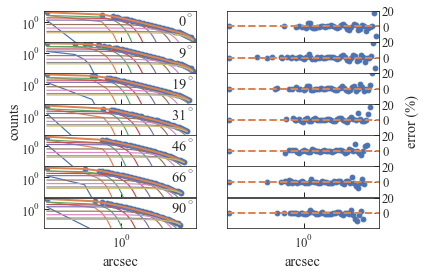

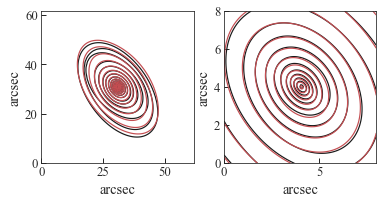

In [31]:
img = model_image

scale = 0.08  # arcsec/pixel
minlevel = 0.002  # counts/pixel
ngauss = 20

sigmapsf = p.sol[:, 1]      # In pixels
normpsf = p.sol[:, 0] / np.sum(p.sol[:, 0])  # total(normpsf)=1


# Here we use FIND_GALAXY directly inside the procedure. Usually you may want
# to experiment with different values of the FRACTION keyword, before adopting
# given values of Eps, Ang, Xc, Yc.
plt.clf()
f = find_galaxy(img, fraction=0.3, plot=1)
plt.show()

# Perform galaxy photometry
plt.clf()
s = sectors_photometry(img, f.eps, f.theta, f.xpeak, f.ypeak,
                       minlevel=minlevel, plot=1)
plt.show()

# Do the actual MGE fit
# *********************** IMPORTANT ***********************************
# For the final publication-quality MGE fit one should include the line
# "from mge_fit_sectors_regularized import mge_fit_sectors_regularized"
# at the top of this file, rename mge_fit_sectors() into
# mge_fit_sectors_regularized() and re-run the procedure.
# See the documentation of mge_fit_sectors_regularized for details.
# *********************************************************************
plt.clf()
m = mge_fit_sectors(s.radius, s.angle, s.counts, f.eps,
                    ngauss=ngauss, sigmapsf=sigmapsf, normpsf=normpsf,
                    scale=scale, plot=1, bulge_disk=0, linear=0)
plt.show()

# Show contour plots of the results
plt.clf()
plt.subplot(121)
mge_print_contours(img.clip(minlevel), f.theta, f.xpeak, f.ypeak, m.sol, scale=scale,
                   binning=7, sigmapsf=sigmapsf, normpsf=normpsf, magrange=9)

# Extract the central part of the image to plot at high resolution.
# The MGE is centered to fractional pixel accuracy to ease visual comparison.

n = 50
img = img[f.xpeak-n:f.xpeak+n, f.ypeak-n:f.ypeak+n]
xc, yc = n - f.xpeak + f.xmed, n - f.ypeak + f.ymed
plt.subplot(122)
mge_print_contours(img, f.theta, xc, yc, m.sol,
                   sigmapsf=sigmapsf, normpsf=normpsf, scale=scale)


In [32]:
sigmas = m.sol[1, :] * np.sqrt(1 - f.eps) * scale
amps = m.sol[0, :]

In [33]:
amps, sigmas

(array([  10.1166058 ,  260.12411704,  840.1345265 , 1283.9562321 ,
        2397.67275685, 2456.47693214, 2104.95888866, 2080.65890571,
        2789.26826004]),
 array([0.05789597, 0.14905521, 0.30011039, 0.52339491, 1.0333712 ,
        2.26157724, 3.73977616, 7.98705854, 9.96309808]))

### Plot the MGE profile and compare with the isophote-based model

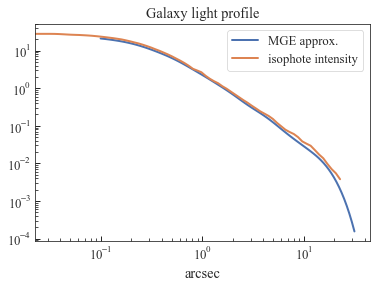

In [68]:
#plt.plot(m.radius * scale, np.sum(m.gauss*m.sol[0, :], axis=1), label='MGE fit', ls='none', marker='o')

xs = np.logspace(-1, 1.5, 100)

mge_profile = 0
for a, s in zip(amps, sigmas):
    mge_profile += a / (2*np.pi) / s**2 * np.exp(-xs**2/2./s**2) / 200 
    # needed division by ~200 to match the amplitudes, however comparing the profile shapes is the goal here

amp = interp1d(xs, mge_profile)(3.2) * 8.

plt.plot(xs, mge_profile, label='MGE approx.', lw=2)
plt.plot(isolist_full.to_table()['sma'] * 0.08 * np.sqrt(1 - f.eps), 
         isolist_full.to_table()['intens'], label='isophote intensity', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.title('Galaxy light profile')
plt.xlabel('arcsec')
plt.legend()
plt.show()
